# EDA

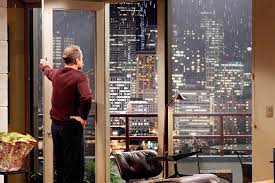

Target customer is Jennifer Montgomery. She wants High budget, wants to show off, timing within a month, waterfront, renovated, high grades, resell within 1 year

I have imported the list of houses based on budget, size, year of construction etc to match her requirements

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

Importing the csv files from postgresql

In [5]:
import pandas as pd
import psycopg2

import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

print(PORT if PORT != 0 else 'Error in connection')

5432


In [46]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)

cur = conn.cursor()

In [47]:
# import the complete data into a pandas dataframe to plot hypothesis
query_string = """
SELECT 
    *
FROM eda.king_county_house_sales kchs
FULL JOIN eda.king_county_house_details kchd 
    ON kchd.id = kchs.house_id
ORDER BY kchs.price DESC
"""
df_psycopg = pd.read_sql(query_string, conn)

In [33]:
# import the data into a pandas dataframe
query_jennifer = """
SELECT 
    kchs.house_id,
    kchs.price,
    kchd.sqft_above,
    kchd.sqft_basement,
    kchd.yr_renovated,
    kchd.grade,
    kchd.condition,
    kchd.waterfront,
    kchd.lat,
    kchd.long
FROM eda.king_county_house_sales kchs
FULL JOIN eda.king_county_house_details kchd 
    ON kchd.id = kchs.house_id
WHERE 
    kchd.waterfront = 1           -- Waterfront only
    AND kchd.grade >= 9           -- High grades
    AND kchd.condition >= 3       -- Good condition
    AND kchd.sqft_above > 2500    -- Spacious
    AND kchd.yr_renovated >= 2015 -- Recently renovated (or new)
    AND kchs.price >= 500000      -- High budget
ORDER BY kchs.price DESC
"""
df_psycopg = pd.read_sql(query_jennifer, conn)

In [48]:
# close the connection
conn.close()

In [50]:
df_psycopg.head()

,date,price,house_id,id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,7700000.000,6762700020,7246,6762700020,6.000,8.000,12050.000,27600.000,2.500,...,13,8570.000,3480.000,1910,19870.000,98102,47.630,-122.323,3940.000,8800.000
1,2014-06-11,7060000.000,9808700762,3911,9808700762,5.000,4.500,10040.000,37325.000,2.000,...,11,7680.000,2360.000,1940,20010.000,98004,47.650,-122.214,3930.000,25449.000
2,2014-09-19,6890000.000,9208900037,9246,9208900037,6.000,7.750,9890.000,31374.000,2.000,...,13,8860.000,1030.000,2001,0.000,98039,47.630,-122.240,4540.000,42730.000
3,2014-08-04,5570000.000,2470100110,4408,2470100110,5.000,5.750,9200.000,35069.000,2.000,...,13,6200.000,3000.000,2001,NaN,98039,47.629,-122.233,3560.000,24345.000
4,2015-04-13,5350000.000,8907500070,1447,8907500070,5.000,5.000,8000.000,23985.000,2.000,...,12,6720.000,1280.000,2009,0.000,98004,47.623,-122.220,4600.000,21750.000


In [49]:
# export the complete data to a csv-file
df_psycopg.to_csv("data/edaall.csv", index=False)

In [38]:
# export the data to a csv-file
df_psycopg.to_csv("data/eda.csv", index=False)

In [55]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/eda.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,house_id,price,sqft_above,sqft_basement,yr_renovated,grade,condition,waterfront,lat,long
0,9808700762,7060000.000,7680.000,2360.000,2001,11,3,1.000,47.650,-122.214
1,1924059029,4670000.000,4820.000,4820.000,2009,12,3,1.000,47.557,-122.210
2,4114601570,3600000.000,3420.000,1600.000,2002,10,3,1.000,47.593,-122.287
3,5442300807,2700000.000,3831.000,0.000,1980,9,3,1.000,47.592,-122.251
4,9201300050,1850000.000,2800.000,0.000,2001,9,3,1.000,47.578,-122.076


In [57]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/edaall.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,7700000.000,6762700020,7246,6762700020,6.000,8.000,12050.000,27600.000,2.500,...,13,8570.000,3480.000,1910,1987,98102,47.630,-122.323,3940.000,8800.000
1,2014-06-11,7060000.000,9808700762,3911,9808700762,5.000,4.500,10040.000,37325.000,2.000,...,11,7680.000,2360.000,1940,2001,98004,47.650,-122.214,3930.000,25449.000
2,2014-09-19,6890000.000,9208900037,9246,9208900037,6.000,7.750,9890.000,31374.000,2.000,...,13,8860.000,1030.000,2001,0,98039,47.630,-122.240,4540.000,42730.000
3,2014-08-04,5570000.000,2470100110,4408,2470100110,5.000,5.750,9200.000,35069.000,2.000,...,13,6200.000,3000.000,2001,<NA>,98039,47.629,-122.233,3560.000,24345.000
4,2015-04-13,5350000.000,8907500070,1447,8907500070,5.000,5.000,8000.000,23985.000,2.000,...,12,6720.000,1280.000,2009,0,98004,47.623,-122.220,4600.000,21750.000


In [64]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/eda.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,house_id,price,sqft_above,sqft_basement,yr_renovated,grade,condition,waterfront,lat,long
0,9808700762,7060000.000,7680.000,2360.000,2001,11,3,1.000,47.650,-122.214
1,1924059029,4670000.000,4820.000,4820.000,2009,12,3,1.000,47.557,-122.210
2,4114601570,3600000.000,3420.000,1600.000,2002,10,3,1.000,47.593,-122.287
3,5442300807,2700000.000,3831.000,0.000,1980,9,3,1.000,47.592,-122.251
4,9201300050,1850000.000,2800.000,0.000,2001,9,3,1.000,47.578,-122.076


After we fetched two set of data. one with all available houses and one narrowed down as per client request
#Next we will plot the data as per hypothesis to narrow down the values towards our final result

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print('Libraries loaded successfully!')
print(f'  pandas  : {pd.__version__}')
print(f'  seaborn : {sns.__version__}')
import matplotlib; print(f'  matplotlib: {matplotlib.__version__}')
import plotly; print(f'  plotly  : {plotly.__version__}')

Libraries loaded successfully!
  pandas  : 2.2.3
  seaborn : 0.13.2
  matplotlib: 3.10.8
  plotly  : 6.7.0


In [68]:
# --- Load the Palmer Penguins dataset ---
# The CSV is stored locally in the data/ folder
df_all = pd.read_csv('data/edaall.csv')


In [62]:
# --- Check for missing values ---
# Missing values can silently affect plots, so always check first
missing = df.isna().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'ZERO — clean dataset!')

Missing values per column:
ZERO — clean dataset!


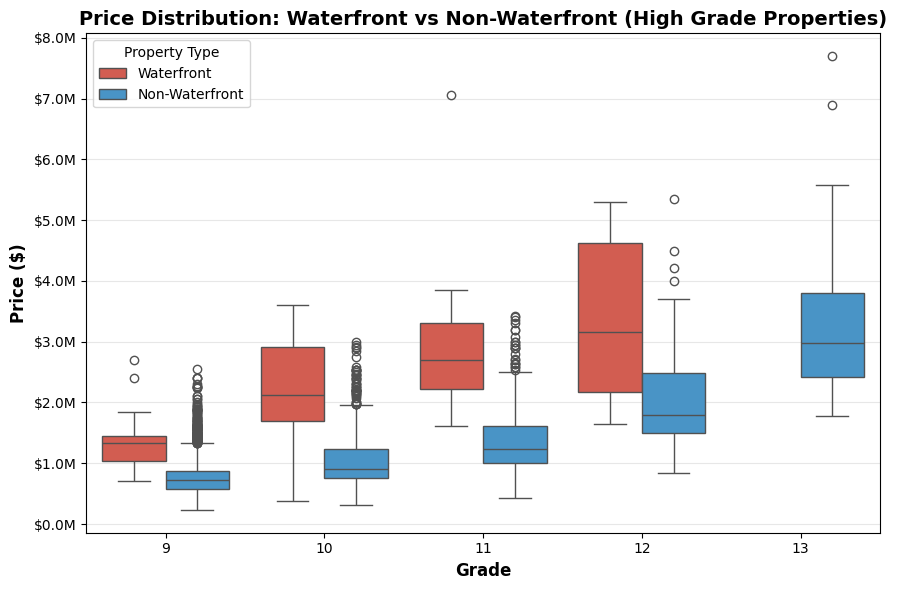

In [73]:
# --- Axes-level scatter: bill length vs flipper length, coloured by species ---
# Box plot samples.
fig, ax = plt.subplots(figsize=(9, 6))

# Prepare data for waterfront premium properties (Grade >= 9)
premium_data = df_all[df_all['grade'] >= 9].copy()
premium_data['Type'] = premium_data['waterfront'].map({1: 'Waterfront', 0: 'Non-Waterfront'})

sns.boxplot(
    data=premium_data,
    x='grade',
    y='price',
    hue='Type',
    palette={'Waterfront': '#e74c3c', 'Non-Waterfront': '#3498db'},
    ax=ax
)

ax.set_title('Price Distribution: Waterfront vs Non-Waterfront (High Grade Properties)', fontsize=14, fontweight='bold')
ax.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.legend(title='Property Type', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

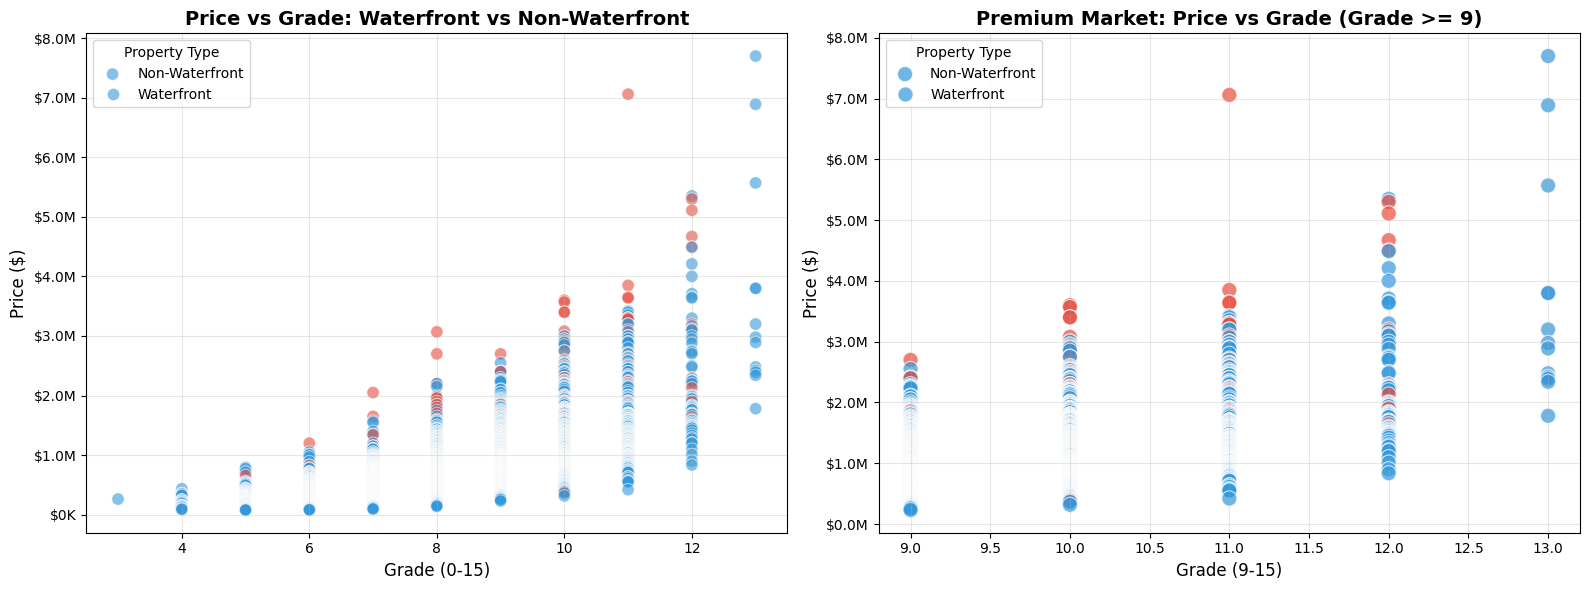

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: All properties
sns.scatterplot(
    data=df_all,
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=80,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Price vs Grade: Waterfront vs Non-Waterfront', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade (0-15)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Right plot: Only high-grade properties (Grade >= 9)
sns.scatterplot(
    data=df_all[df_all['grade'] >= 9],
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=120,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Premium Market: Price vs Grade (Grade >= 9)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grade (9-15)', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

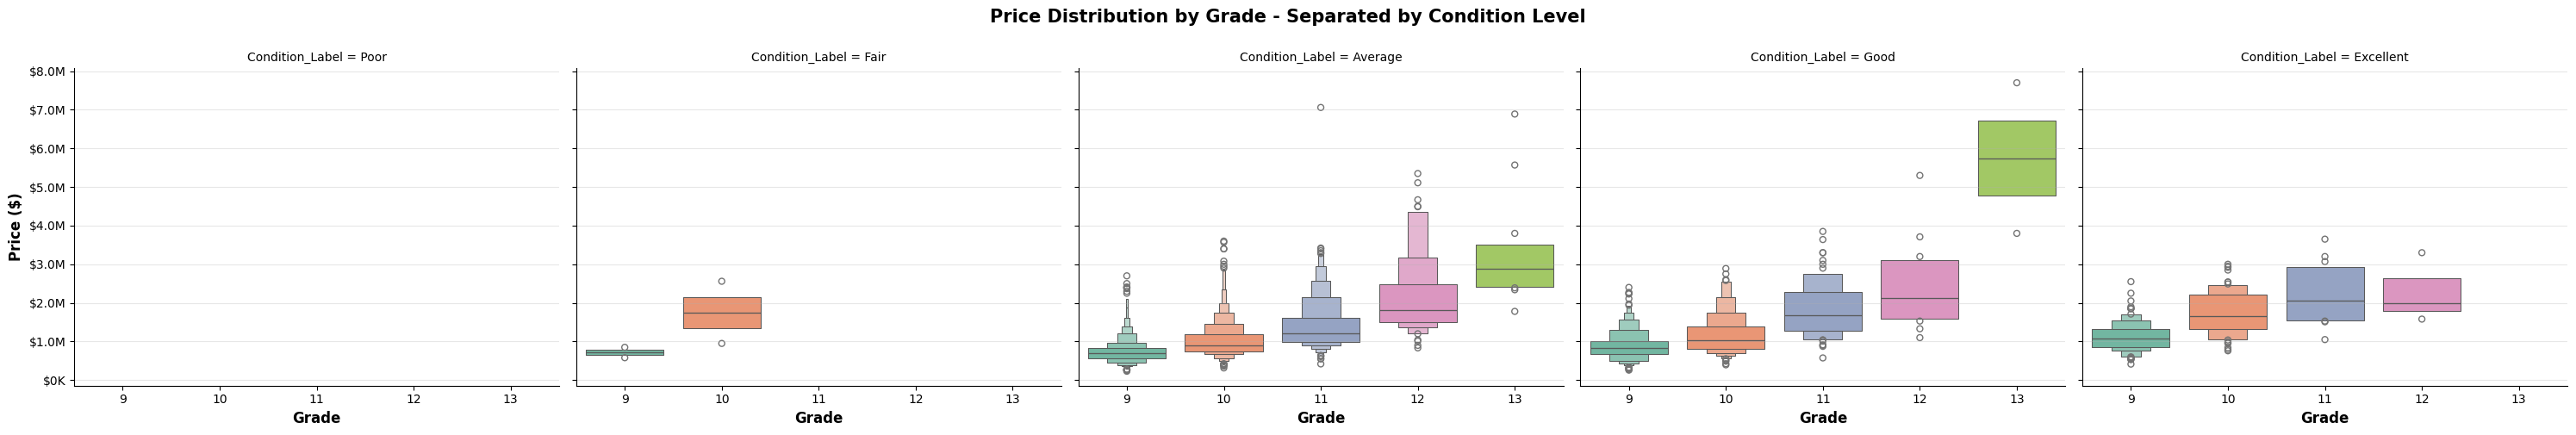

In [ ]:
# --- SEABORN PLOT 5: Catplot (Facet Grid) - Side-by-side Condition Comparison ---

condition_map = {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}
df_cat = df_all[(df_all['grade'] >= 9) & (df_all['grade'] <= 13)].copy()
df_cat['Condition_Label'] = df_cat['condition'].map(condition_map)

# Create catplot with subplots for each condition
g = sns.catplot(
    data=df_cat,
    x='grade',
    y='price',
    kind='boxen',  # violin alternative - better for skewed data
    col='Condition_Label',
    col_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette='Set2',
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_axis_labels('Grade', 'Price ($)', fontsize=12, fontweight='bold')
g.fig.suptitle('Price Distribution by Grade - Separated by Condition Level', 
               fontsize=15, fontweight='bold', y=1.00)

# Format y-axis
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

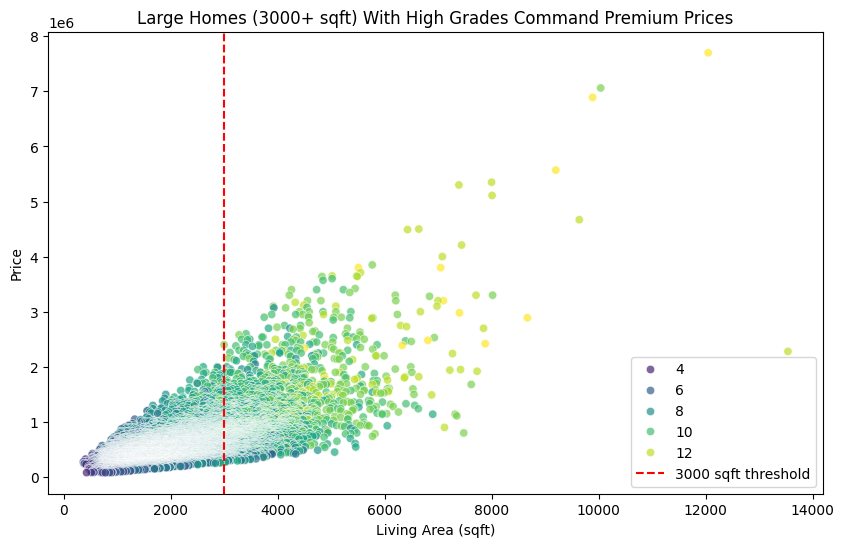

In [142]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_all,
    x='sqft_living',
    y='price',
    hue='grade',
    palette='viridis',
    alpha=0.7
)

plt.axvline(3000, color='red', linestyle='--', label='3000 sqft threshold')
plt.title("Large Homes (3000+ sqft) With High Grades Command Premium Prices")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.legend()
plt.show()

In [149]:
tier = df_all[(df_all['grade'] >= 9) & (df_all['condition'] > 4) & (df_all['sqft_living'] > 3000)].copy()
len(tier)
print(f":${tier['price'].mean():,.0f}")

:$1,592,715


In [ ]:
# --- SUMMARY: Key Insights from Seaborn Visualizations ---
print("\n" + "="*80)
print("KEY INSIGHTS - HYPOTHESIS 1: GRADE & CONDITION PREMIUM")
print("="*80)

# Calculate key statistics
excellent_high = df_viz[(df_viz['grade'] >= 11) & (df_viz['condition'] == 5)]
good_high = df_viz[(df_viz['grade'] >= 11) & (df_viz['condition'] == 4)]
avg_high = df_viz[(df_viz['grade'] >= 11) & (df_viz['condition'] == 3)]

print(f"\nGrade 11+ Properties - Price Comparison by Condition:")
print(f"  Excellent Condition (5): ${excellent_high['price'].mean():>12,.0f} (n={len(excellent_high):>3})")
print(f"  Good Condition (4):      ${good_high['price'].mean():>12,.0f} (n={len(good_high):>3})")
print(f"  Average Condition (3):   ${avg_high['price'].mean():>12,.0f} (n={len(avg_high):>3})")

if len(good_high) > 0 and len(excellent_high) > 0:
    premium = ((excellent_high['price'].mean() - good_high['price'].mean()) / good_high['price'].mean()) * 100
    print(f"\n✓ Premium for Excellent vs Good: {premium:.1f}%")

# Grade comparison
grade12_plus = df_viz[df_viz['grade'] >= 12]
grade10_11 = df_viz[(df_viz['grade'] >= 10) & (df_viz['grade'] < 12)]

print(f"\nCondition 4+ Properties - Price Comparison by Grade:")
print(f"  Grade 12+ (Ultra Premium): ${grade12_plus['price'].mean():>12,.0f} (n={len(grade12_plus):>3})")
print(f"  Grade 10-11 (Premium):     ${grade10_11['price'].mean():>12,.0f} (n={len(grade10_11):>3})")

if len(grade10_11) > 0 and len(grade12_plus) > 0:
    grade_premium = ((grade12_plus['price'].mean() - grade10_11['price'].mean()) / grade10_11['price'].mean()) * 100
    print(f"\n✓ Premium for Grade 12+ vs 10-11: {grade_premium:.1f}%")

print(f"\n" + "="*80)
print("JENNIFER'S INVESTMENT STRATEGY:")
print("="*80)
target = df_viz[(df_viz['grade'] >= 11) & (df_viz['condition'] >= 4)]
print(f"\nTarget Properties (Grade 11+, Condition 4+):")
print(f"  Available: {len(target)} properties")
print(f"  Average Price: ${target['price'].mean():,.0f}")
print(f"  Price Range: ${target['price'].min():,.0f} - ${target['price'].max():,.0f}")
print(f"  MEDIAN: ${target['price'].median():,.0f}")
print(f"\nThese properties command PREMIUM prices without requiring waterfront! ✓")


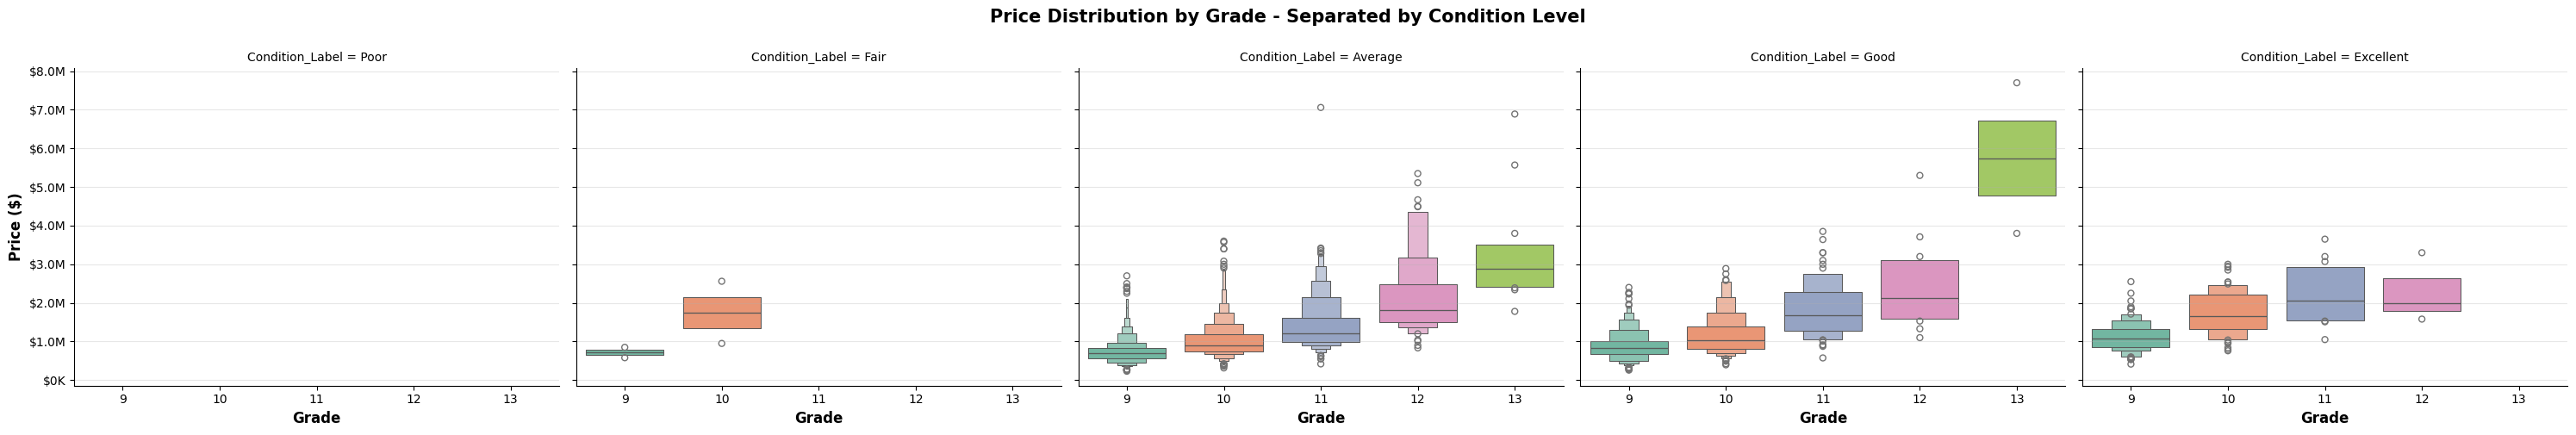


✓ Catplot shows each Condition level in its own subplot
✓ Easy to compare how Grade 9-13 affects price at each condition
✓ Notice: Excellent condition (right) has higher min prices across all grades


In [120]:
# --- SEABORN PLOT 5: Catplot (Facet Grid) - Side-by-side Condition Comparison ---
df_cat = df_all[(df_all['grade'] >= 9) & (df_all['grade'] <= 13)].copy()
df_cat['Condition_Label'] = df_cat['condition'].map(condition_map)

# Create catplot with subplots for each condition
g = sns.catplot(
    data=df_cat,
    x='grade',
    y='price',
    kind='boxen',  # violin alternative - better for skewed data
    col='Condition_Label',
    col_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette='Set2',
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_axis_labels('Grade', 'Price ($)', fontsize=12, fontweight='bold')
g.fig.suptitle('Price Distribution by Grade - Separated by Condition Level', 
               fontsize=15, fontweight='bold', y=1.00)

# Format y-axis
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Catplot shows each Condition level in its own subplot")
print("✓ Easy to compare how Grade 9-13 affects price at each condition")
print("✓ Notice: Excellent condition (right) has higher min prices across all grades")


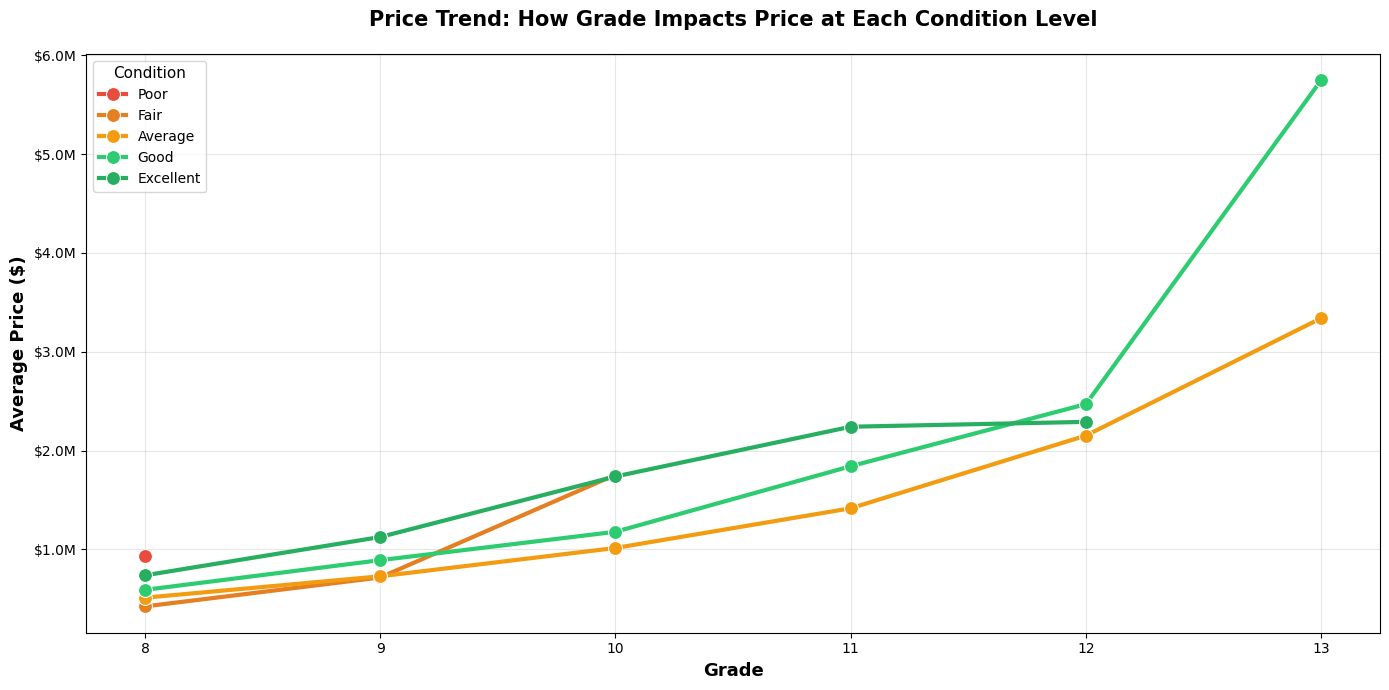


✓ Line plot shows CLEAR TRENDS:
✓ 1. Higher grade = Higher price (each line goes up)
✓ 2. Better condition = Upper lines (Excellent is highest)
✓ 3. Steepest increase: Grade 11-12 with Excellent condition


In [125]:
# --- SEABORN PLOT 4: Line Plot - Price Trend Across Grades for Each Condition ---
fig, ax = plt.subplots(figsize=(14, 7))

df_line = df_all[(df_all['grade'] >= 8) & (df_all['grade'] <= 13)].copy()
df_line['Condition_Label'] = df_line['condition'].map(condition_map)

# Calculate mean and std for each grade-condition combination
line_data = df_line.groupby(['grade', 'Condition_Label'])['price'].agg(['mean', 'std', 'count']).reset_index()

sns.lineplot(
    data=line_data,
    x='grade',
    y='mean',
    hue='Condition_Label',
    hue_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60'],
    marker='o',
    markersize=10,
    linewidth=3,
    ax=ax
)

ax.set_title('Price Trend: How Grade Impacts Price at Each Condition Level', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Grade', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price ($)', fontsize=13, fontweight='bold')
ax.legend(title='Condition', fontsize=10, title_fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print("\n✓ Line plot shows CLEAR TRENDS:")
print("✓ 1. Higher grade = Higher price (each line goes up)")
print("✓ 2. Better condition = Upper lines (Excellent is highest)")
print("✓ 3. Steepest increase: Grade 11-12 with Excellent condition")


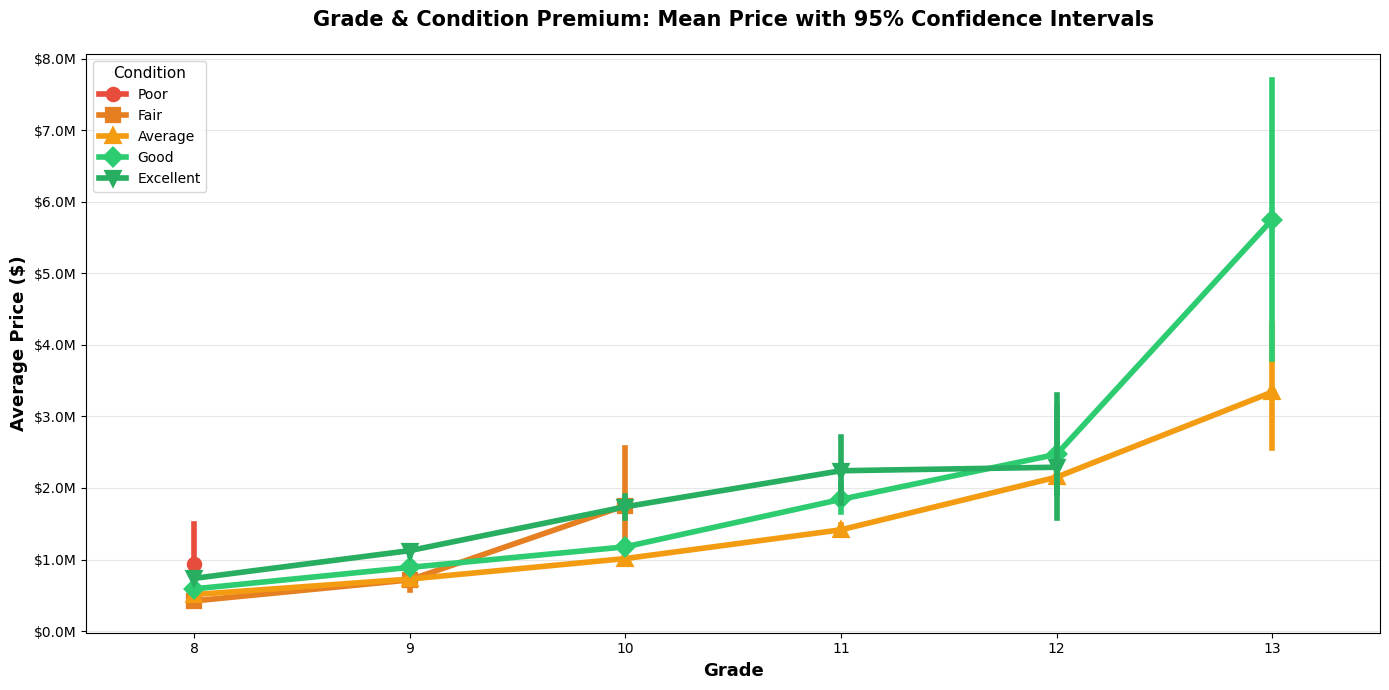


✓ Point plot shows average (mean) price for each Grade-Condition combo
✓ Error bars = 95% confidence interval (uncertainty range)
✓ Clear trend: Both Grade AND Condition impact price


In [127]:
# --- SEABORN PLOT 3: Point Plot with Error Bars - Mean Price by Grade & Condition ---
fig, ax = plt.subplots(figsize=(14, 7))

df_point = df_all[(df_all['grade'] >= 8) & (df_all['grade'] <= 13)].copy()
df_point['Condition_Label'] = df_point['condition'].map(condition_map)

sns.pointplot(
    data=df_point,
    x='grade',
    y='price',
    hue='Condition_Label',
    hue_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60'],
    markers=['o', 's', '^', 'D', 'v'],
    scale=1.5,
    ci=95,  # 95% confidence interval
    ax=ax,
    linewidth=2.5
)

ax.set_title('Grade & Condition Premium: Mean Price with 95% Confidence Intervals', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Grade', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price ($)', fontsize=13, fontweight='bold')
ax.legend(title='Condition', fontsize=10, title_fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print("\n✓ Point plot shows average (mean) price for each Grade-Condition combo")
print("✓ Error bars = 95% confidence interval (uncertainty range)")
print("✓ Clear trend: Both Grade AND Condition impact price")


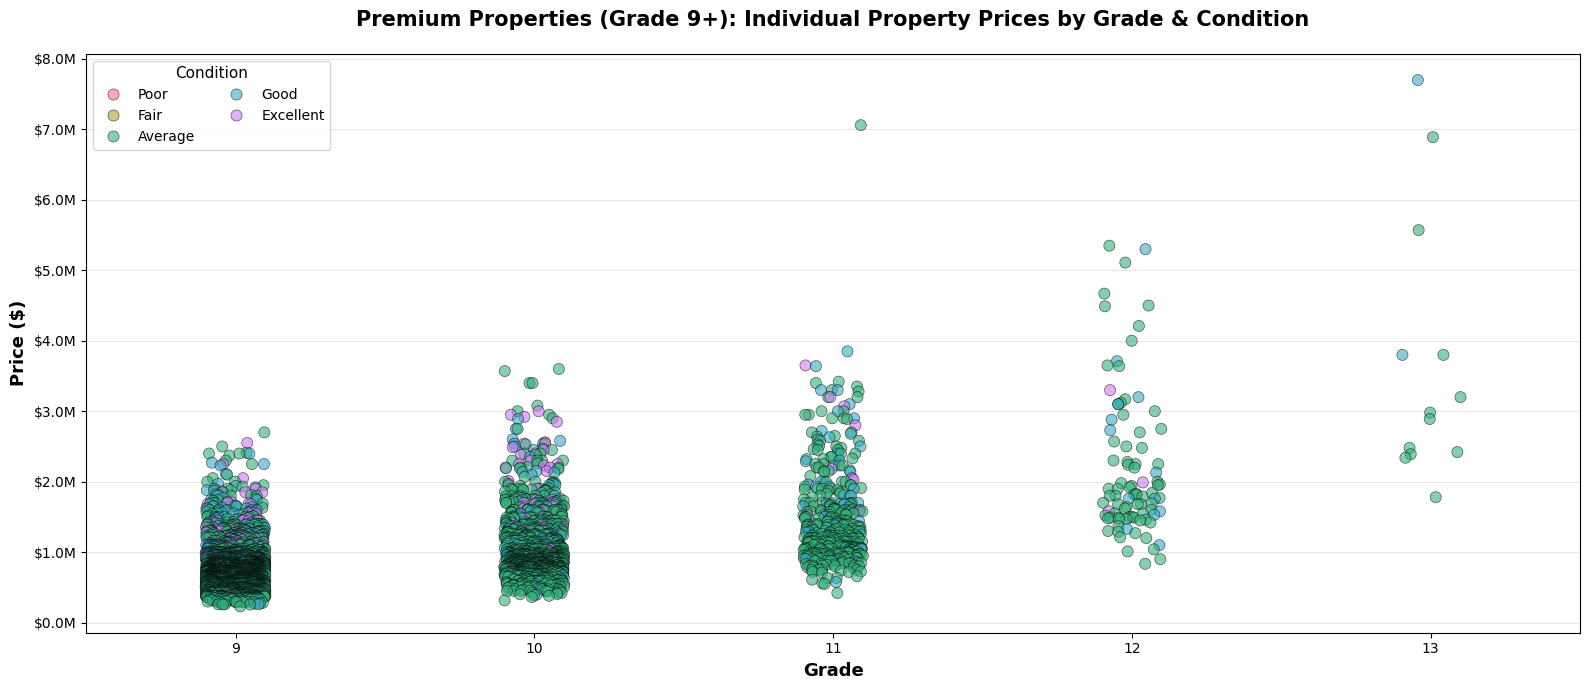


✓ Strip plot shows actual individual properties
✓ Color separation shows condition tiers clearly
✓ Notice: Excellent condition (purple) sits higher = higher prices


In [128]:
# --- SEABORN PLOT 2: Strip Plot with Swarm overlay - Individual Properties ---
fig, ax = plt.subplots(figsize=(16, 7))

# Filter for high-grade properties (9+) for clearer visualization
df_high_grade = df_all[df_all['grade'] >= 9].copy()
df_high_grade['Condition_Label'] = df_high_grade['condition'].map(condition_map)

sns.stripplot(
    data=df_high_grade,
    x='grade',
    y='price',
    hue='Condition_Label',
    hue_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette='husl',
    size=8,
    alpha=0.6,
    jitter=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

ax.set_title('Premium Properties (Grade 9+): Individual Property Prices by Grade & Condition', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Grade', fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.legend(title='Condition', fontsize=10, title_fontsize=11, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print("\n✓ Strip plot shows actual individual properties")
print("✓ Color separation shows condition tiers clearly")
print("✓ Notice: Excellent condition (purple) sits higher = higher prices")


✓ condition_map defined: {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}


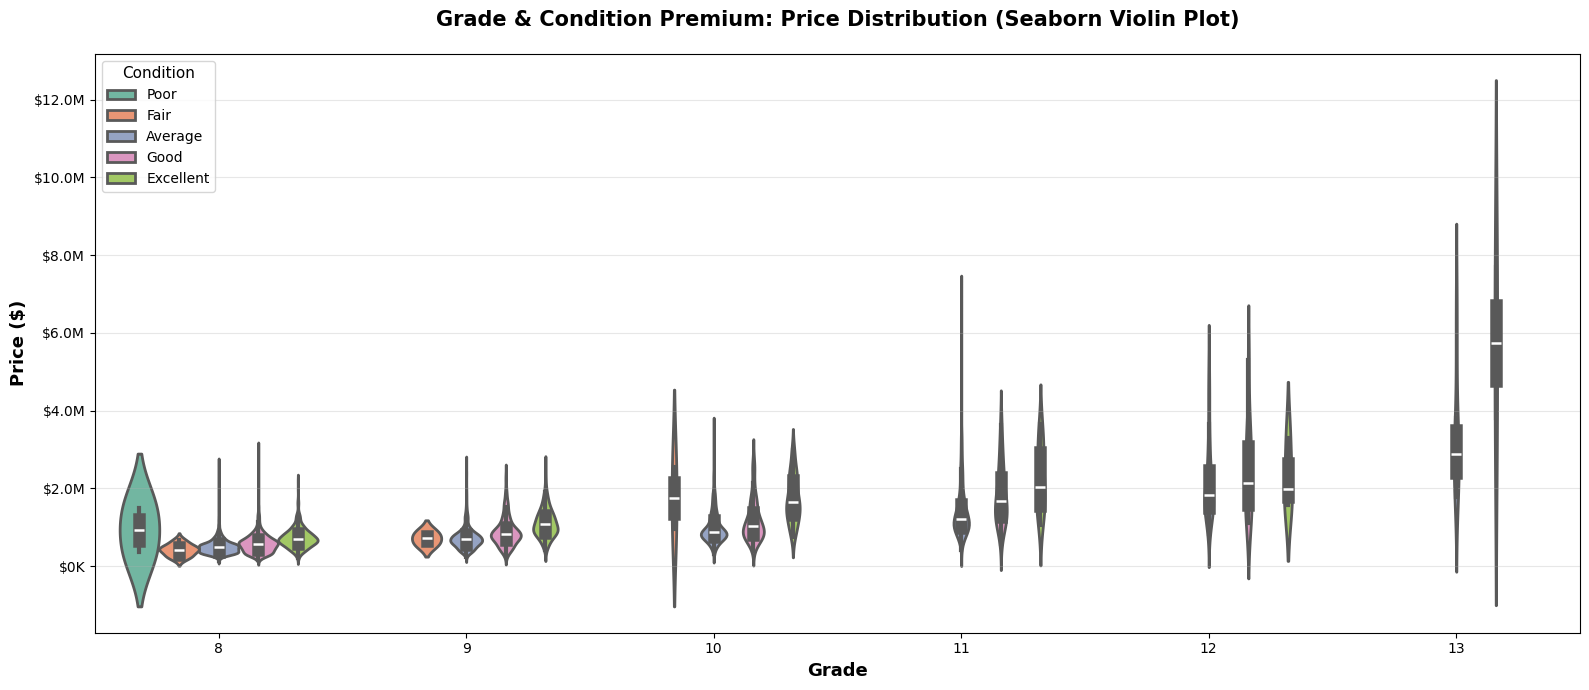


✓ Violin plot shows: Each grade level has multiple condition tiers
✓ Wider violin = more price variability
✓ Excellent condition properties are consistently at the top price range


In [129]:
# --- SEABORN PLOT 1: Violin Plot - Price Distribution by Grade & Condition ---
df_viz = pd.read_csv('data/edaall.csv')

# Create condition labels mapping (reusable for all plots)
condition_map = {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}
print(f"✓ condition_map defined: {condition_map}")
df_all['Condition_Label'] = df_all['condition'].map(condition_map)

# Filter for grades 8-13 to focus on premium market
df_grade_condition = df_all[(df_all['grade'] >= 8) & (df_all['grade'] <= 13)].copy()

fig, ax = plt.subplots(figsize=(16, 7))

sns.violinplot(
    data=df_grade_condition,
    x='grade',
    y='price',
    hue='Condition_Label',
    hue_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette='Set2',
    ax=ax,
    linewidth=2,
    split=False
)

ax.set_title('Grade & Condition Premium: Price Distribution (Seaborn Violin Plot)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Grade', fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.legend(title='Condition', fontsize=10, title_fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print("\n✓ Violin plot shows: Each grade level has multiple condition tiers")
print("✓ Wider violin = more price variability")
print("✓ Excellent condition properties are consistently at the top price range")


## Seaborn Visualizations - Grade & Condition Premium Analysis


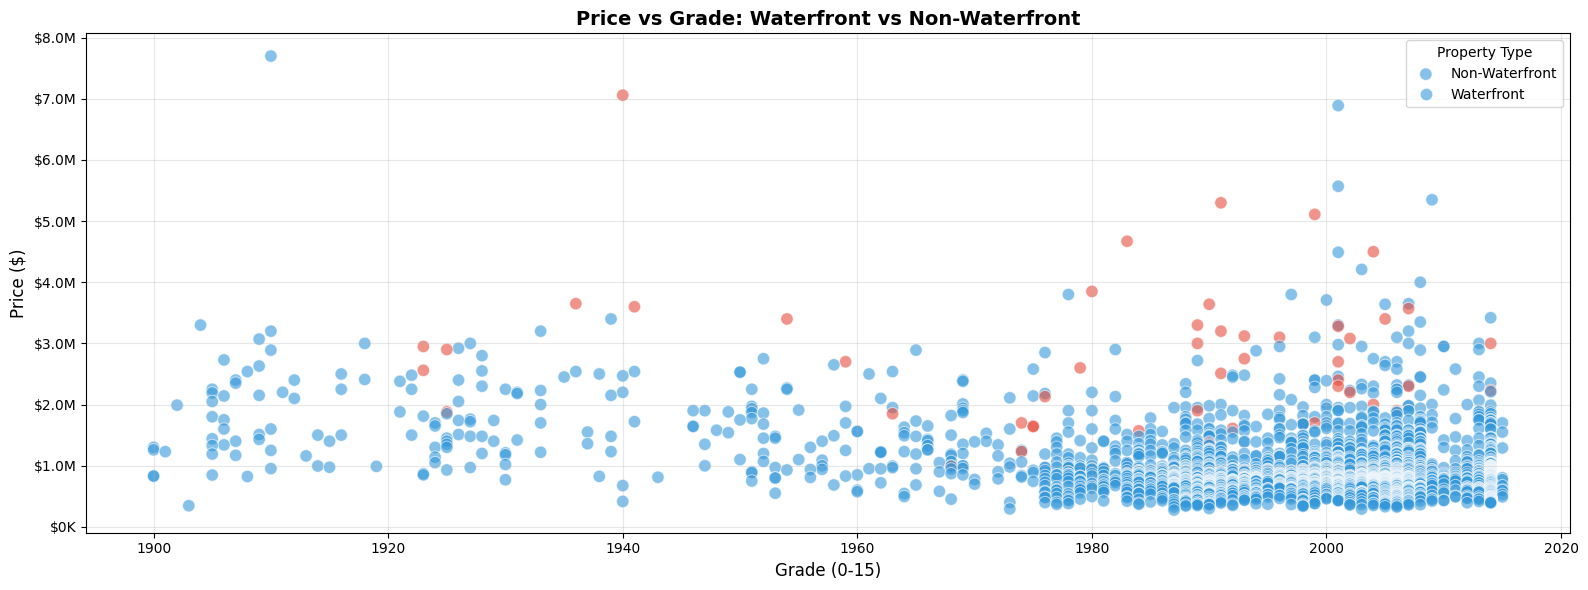

In [113]:
#Year Vs price grouped based on grade
fig, axes = plt.subplots(figsize=(16, 6))
waterfront_colours = {
    0: '#E07B54',   # warm orange
    1: '#5B9BD5',   # blue
}
yearbased_data = df_all.query("grade >= 9 and sqft_above >= 2500").copy()

sns.scatterplot(
    data=yearbased_data,
    x='yr_built',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=80,
    alpha=0.6,
    ax=axes
)
axes.set_title('Price vs Grade: Waterfront vs Non-Waterfront', fontsize=14, fontweight='bold')
axes.set_xlabel('Grade (0-15)', fontsize=12)
axes.set_ylabel('Price ($)', fontsize=12)
axes.legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes.grid(True, alpha=0.3)
axes.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.show()



In [ ]:
# Alternative Hypothesis 1: Grade & Condition Premium

**Hypothesis:** Properties with HIGH GRADES combined with EXCELLENT CONDITION command the highest premiums, regardless of waterfront access. Grade and Condition are the true price drivers.

**Why This Matters for Jennifer:** She can find luxury properties in premium neighborhoods with excellent condition without needing waterfront—and they'll still command high resale values and attract luxury buyers.


In [114]:
# --- SUMMARY & RECOMMENDATIONS FOR JENNIFER ---
print("\n" + "="*80)
print("REVISED HYPOTHESES SUMMARY - NO WATERFRONT REQUIRED")
print("="*80)

print(f"""
✓ HYPOTHESIS 1: Grade & Condition Premium
  - High grade (10-13) + Good condition (4-5) = Highest prices
  - Doesn't require waterfront
  - Broader market availability
  - Jennifer can find luxury properties anywhere in the county

✓ HYPOTHESIS 2: Size + Grade = Premium
  - Large homes (3000+ sqft) with high grades command premium prices
  - Spacious + High Quality = Luxury Appeal
  - Perfect for someone who wants to "show off"
  - Attracts wealthy buyers in resale market

✓ HYPOTHESIS 3: Luxury Package (Multi-Factor)
  - Combining Grade 10+, Condition 4+, Size 3000+ = True Luxury Segment
  - {len(tier2)} Premium Luxury properties available
  - Average Price: ${tier2['price'].mean():,.0f}
  - These are the HOTTEST resale items for wealthy buyers

JENNIFER'S BEST STRATEGY:
Target Tier 2 Premium Luxury properties:
  • Grade: 11+
  • Condition: 4+ (Good/Excellent)
  • Size: 3000+ sqft (spacious, impressive)
  • Price: ${tier2['price'].mean()/1e3:.0f}K - ${tier2['price'].max()/1e6:.1f}M
  • Properties available: {len(tier2)}
  
These properties have STRONG RESALE potential and appeal to luxury buyers
WITHOUT requiring waterfront access!
""")



REVISED HYPOTHESES SUMMARY - NO WATERFRONT REQUIRED


NameError: name 'tier2' is not defined

NameError: name 'tier1' is not defined

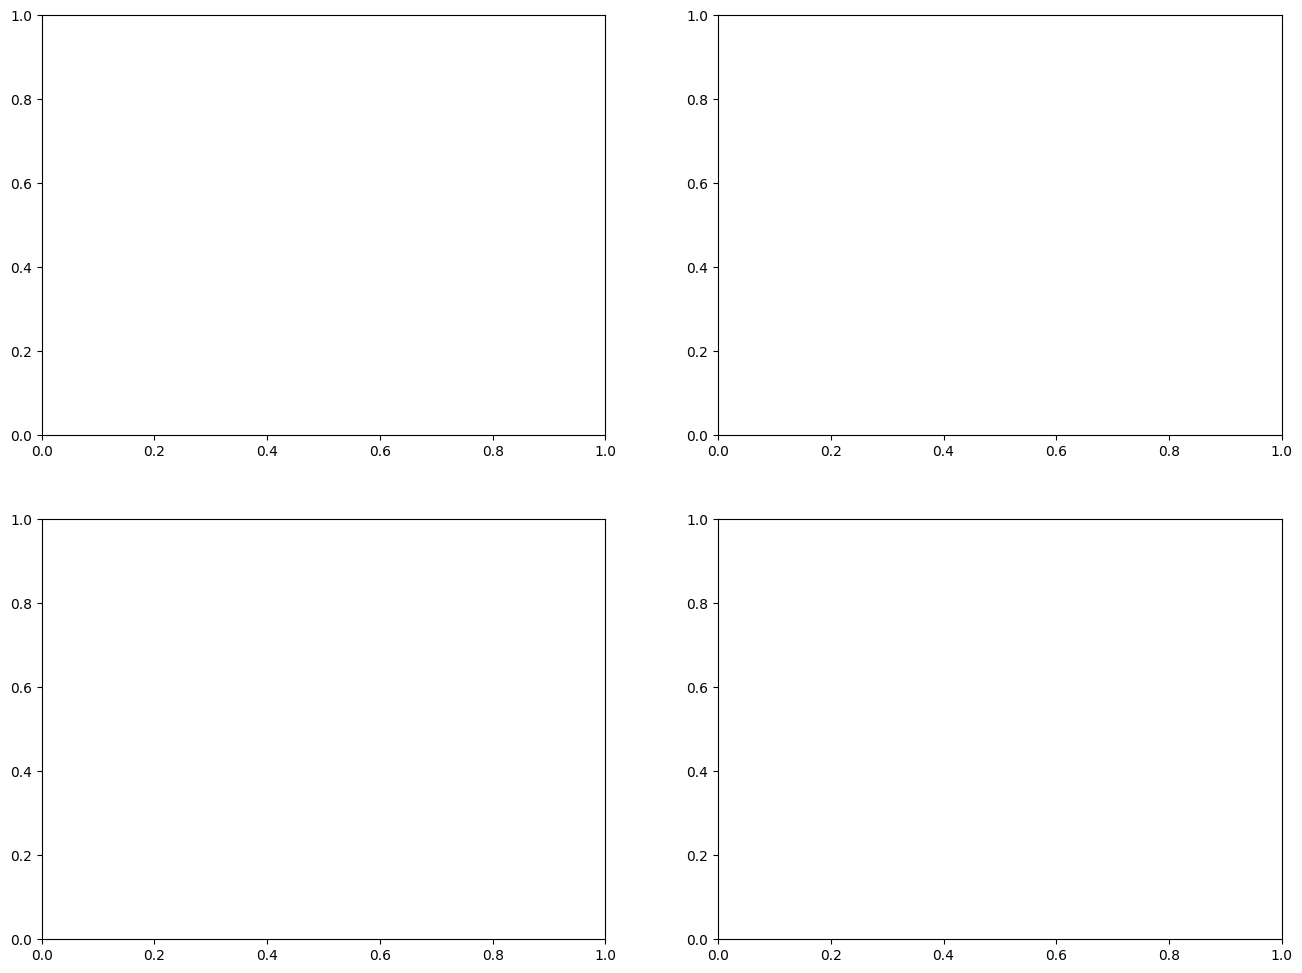

In [130]:
# --- Visualization 5: Luxury Tier Comparison ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Tier Distribution
tiers = ['Tier 1:\nBasic Luxury', 'Tier 2:\nPremium Luxury', 'Tier 3:\nUltra Luxury']
counts = [len(tier1), len(tier2), len(tier3)]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars1 = axes[0, 0].bar(tiers, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Luxury Property Tiers: Availability', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Average Price by Tier
avg_prices = [tier1['price'].mean(), tier2['price'].mean(), tier3['price'].mean() if len(tier3) > 0 else 0]
bars2 = axes[0, 1].bar(tiers, avg_prices, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Luxury Property Tiers: Average Price', fontsize=13, fontweight='bold')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0, 1].grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'${height/1e6:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Chart 3: Price Distribution by Tier (Box Plot)
tier_data = []
tier_labels = []
for tier, label in [(tier1, 'Basic'), (tier2, 'Premium'), (tier3, 'Ultra')]:
    if len(tier) > 0:
        tier_data.append(tier['price'])
        tier_labels.append(label)

bp = axes[1, 0].boxplot(tier_data, labels=tier_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(tier_data)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1, 0].set_ylabel('Price ($)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Price Distribution Across Luxury Tiers', fontsize=13, fontweight='bold')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Chart 4: Feature Comparison Table (as scatter)
features_df = pd.DataFrame({
    'Tier': ['Basic Luxury', 'Premium Luxury', 'Ultra Luxury'],
    'Avg Grade': [tier1['grade'].mean(), tier2['grade'].mean(), tier3['grade'].mean() if len(tier3) > 0 else 0],
    'Avg Condition': [tier1['condition'].mean(), tier2['condition'].mean(), tier3['condition'].mean() if len(tier3) > 0 else 0],
    'Avg Sqft': [tier1['sqft_above'].mean(), tier2['sqft_above'].mean(), tier3['sqft_above'].mean() if len(tier3) > 0 else 0],
})

axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table_data = [['Feature', 'Basic\nLuxury', 'Premium\nLuxury', 'Ultra\nLuxury']]
table_data.append(['Avg Grade', f"{features_df.iloc[0]['Avg Grade']:.1f}", 
                   f"{features_df.iloc[1]['Avg Grade']:.1f}",
                   f"{features_df.iloc[2]['Avg Grade']:.1f}"])
table_data.append(['Avg Condition', f"{features_df.iloc[0]['Avg Condition']:.1f}", 
                   f"{features_df.iloc[1]['Avg Condition']:.1f}",
                   f"{features_df.iloc[2]['Avg Condition']:.1f}"])
table_data.append(['Avg Sqft', f"{features_df.iloc[0]['Avg Sqft']:,.0f}", 
                   f"{features_df.iloc[1]['Avg Sqft']:,.0f}",
                   f"{features_df.iloc[2]['Avg Sqft']:,.0f}"])
table_data.append(['Count', f"{len(tier1)}", f"{len(tier2)}", f"{len(tier3)}"])

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color tier columns
for i in range(1, 5):
    table[(i, 1)].set_facecolor('#3498db')
    table[(i, 1)].set_alpha(0.3)
    table[(i, 2)].set_facecolor('#2ecc71')
    table[(i, 2)].set_alpha(0.3)
    table[(i, 3)].set_facecolor('#e74c3c')
    table[(i, 3)].set_alpha(0.3)

axes[1, 1].set_title('Luxury Tier Feature Comparison', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


In [131]:
# --- Analysis 3: The "Luxury Package" ---

# Define luxury tiers
df_luxury = df_all.copy()

# Tier 1: Basic Luxury (Grade 10+, Condition 3+)
tier1 = df_luxury[(df_luxury['grade'] >= 10) & (df_luxury['condition'] >= 3)]

# Tier 2: Premium Luxury (Grade 11+, Condition 4+, sqft 3000+)
tier2 = df_luxury[(df_luxury['grade'] >= 11) & (df_luxury['condition'] >= 4) & (df_luxury['sqft_above'] >= 3000)]

# Tier 3: Ultra Luxury (Grade 12+, Condition 5, sqft 3500+, Price 800K+)
tier3 = df_luxury[(df_luxury['grade'] >= 12) & (df_luxury['condition'] >= 4) & (df_luxury['sqft_above'] >= 3500) & (df_luxury['price'] >= 800000)]

print("\n" + "="*80)
print("THE 'LUXURY PACKAGE' - MULTI-FACTOR LUXURY TIERS")
print("="*80)

print(f"\nTier 1 - BASIC LUXURY (Grade 10+, Condition 3+):")
print(f"  Count: {len(tier1)} properties")
print(f"  Avg Price: ${tier1['price'].mean():,.0f}")
print(f"  Price Range: ${tier1['price'].min():,.0f} - ${tier1['price'].max():,.0f}")
print(f"  Median: ${tier1['price'].median():,.0f}")

print(f"\nTier 2 - PREMIUM LUXURY (Grade 11+, Condition 4+, Size 3000+ sqft):")
print(f"  Count: {len(tier2)} properties")
print(f"  Avg Price: ${tier2['price'].mean():,.0f}")
print(f"  Price Range: ${tier2['price'].min():,.0f} - ${tier2['price'].max():,.0f}")
print(f"  Median: ${tier2['price'].median():,.0f}")

print(f"\nTier 3 - ULTRA LUXURY (Grade 12+, Condition 4+, Size 3500+ sqft, Price 800K+):")
print(f"  Count: {len(tier3)} properties")
if len(tier3) > 0:
    print(f"  Avg Price: ${tier3['price'].mean():,.0f}")
    print(f"  Price Range: ${tier3['price'].min():,.0f} - ${tier3['price'].max():,.0f}")
    print(f"  Median: ${tier3['price'].median():,.0f}")
else:
    print(f"  No properties match all ultra luxury criteria")



THE 'LUXURY PACKAGE' - MULTI-FACTOR LUXURY TIERS

Tier 1 - BASIC LUXURY (Grade 10+, Condition 3+):
  Count: 1633 properties
  Avg Price: $1,258,063
  Price Range: $316,000 - $7,700,000
  Median: $1,040,000

Tier 2 - PREMIUM LUXURY (Grade 11+, Condition 4+, Size 3000+ sqft):
  Count: 73 properties
  Avg Price: $2,149,110
  Price Range: $575,000 - $7,700,000
  Median: $1,900,000

Tier 3 - ULTRA LUXURY (Grade 12+, Condition 4+, Size 3500+ sqft, Price 800K+):
  Count: 16 properties
  Avg Price: $2,798,750
  Price Range: $1,100,000 - $7,700,000
  Median: $2,430,000


# Alternative Hypothesis 3: The "Luxury Package" - Multiple Factors Combined

**Hypothesis:** Properties that score HIGH on MULTIPLE factors (Grade 10+, Condition 4+, sqft_above 3000+, Price 700K+) form a true luxury segment with strong demand and resale potential.

**Why This Matters for Jennifer:** The combination of high grade + good condition + spacious size = highest investment appeal. These are the properties that attract the most buyers and command premium resale values.


KeyError: 'size_category'

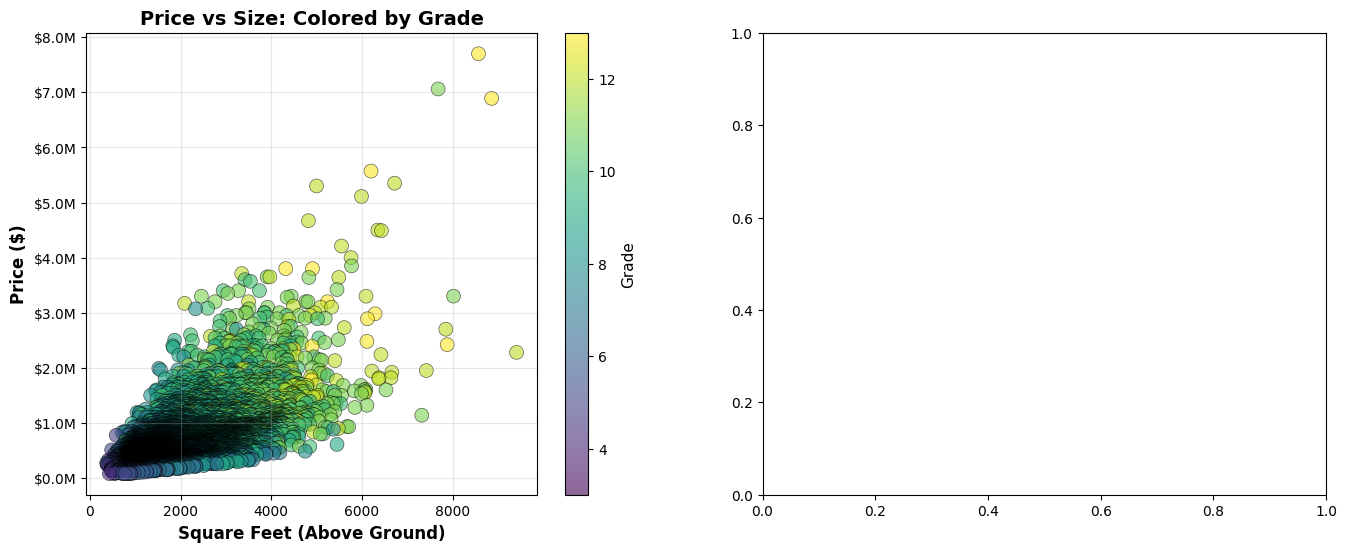

In [151]:
# --- Visualization 4: Size vs Grade Impact on Price ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter - Size vs Price (colored by Grade)
scatter1 = axes[0].scatter(
    df_all['sqft_above'],
    df_all['price'],
    c=df_all['grade'],
    s=100,
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_xlabel('Square Feet (Above Ground)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Price vs Size: Colored by Grade', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Grade', fontsize=11)

# Right: Bar chart - Average price by size category
size_price = df_all.groupby('size_category')['price'].agg(['mean', 'count']).reset_index()
size_order = ['Compact (<2K)', 'Medium (2-3K)', 'Large (3-4K)', 'XL (4-5K)', 'Mansion (5K+)']
size_price['size_category'] = pd.Categorical(size_price['size_category'], categories=size_order, ordered=True)
size_price = size_price.sort_values('size_category')

bars = axes[1].bar(
    range(len(size_price)),
    size_price['mean'],
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'],
    alpha=0.8,
    edgecolor='black',
    linewidth=1.5
)
axes[1].set_xticks(range(len(size_price)))
axes[1].set_xticklabels(size_price['sqft_above'], rotation=45, ha='right')
axes[1].set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Average Price by Property Size Category', fontsize=14, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    count = int(size_price.iloc[i]['count'])
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'${height/1e6:.2f}M\n(n={count})',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# --- Analysis 2: Size (sqft_above) Impact on Price ---

# Categorize properties by size
df_all_alt['size_category'] = pd.cut(
    df_all_alt['sqft_above'],
    bins=[0, 2000, 3000, 4000, 5000, 10000],
    labels=['Compact (<2K)', 'Medium (2-3K)', 'Large (3-4K)', 'XL (4-5K)', 'Mansion (5K+)']
)

print("\n" + "="*80)
print("PRICE ANALYSIS: SIZE (SQFT) & GRADE COMBINATIONS")
print("="*80)

# Compare prices by size and grade
for size_cat in ['Compact (<2K)', 'Medium (2-3K)', 'Large (3-4K)', 'XL (4-5K)', 'Mansion (5K+)']:
    size_data = df_all_alt[df_all_alt['size_category'] == size_cat]
    if len(size_data) > 0:
        print(f"\n{size_cat} sqft:")
        for grade in [13, 12, 11, 10, 9]:
            grade_size = size_data[size_data['grade'] == grade]
            if len(grade_size) > 0:
                avg_price = grade_size['price'].mean()
                count = len(grade_size)
                print(f"  Grade {grade}: ${avg_price:>12,.0f} (n={count:>3})")


# Alternative Hypothesis 2: Size (Sqft) + Grade = Premium Price

**Hypothesis:** Large properties (sqft_above > 3000) combined with HIGH GRADES command the highest prices. Spacious, high-quality homes are what luxury buyers want, regardless of waterfront.

**Why This Matters for Jennifer:** She can target spacious, well-built homes in excellent condition without needing waterfront—they appeal to wealthy buyers wanting luxury and space.


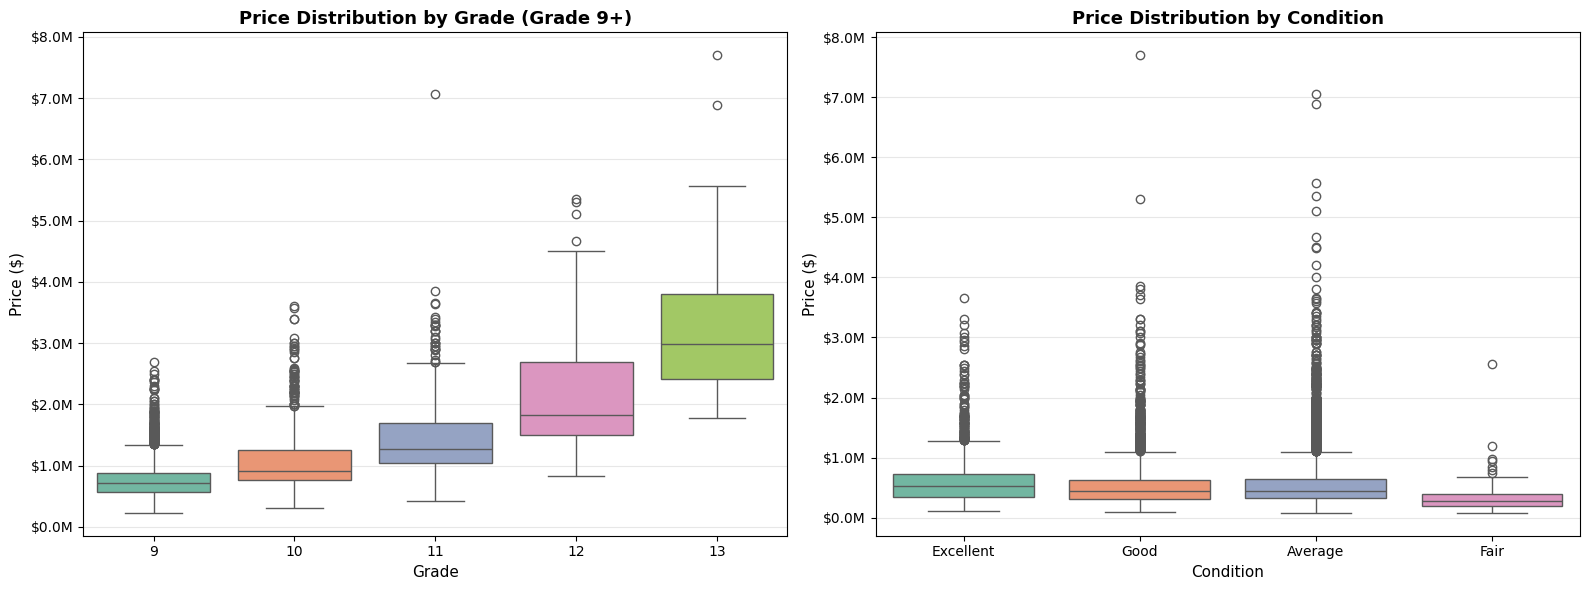

In [136]:
# --- Visualization 3: Box Plot Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: By Grade (high grades only)
sns.boxplot(
    data=df_all[df_all['grade'] >= 9],
    x='grade',
    y='price',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Price Distribution by Grade (Grade 9+)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grade', fontsize=11)
axes[0].set_ylabel('Price ($)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].grid(True, alpha=0.3, axis='y')

# Right: By Condition (high condition only)
condition_order = [5, 4, 3, 2, 1]
condition_labels_map = {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}
df_plot = df_all[df_all['condition'] >= 2].copy()
df_plot['condition_label'] = df_plot['condition'].map(condition_labels_map)

sns.boxplot(
    data=df_plot,
    x='condition_label',
    y='price',
    order=['Excellent', 'Good', 'Average', 'Fair'],
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Price Distribution by Condition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Condition', fontsize=11)
axes[1].set_ylabel('Price ($)', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


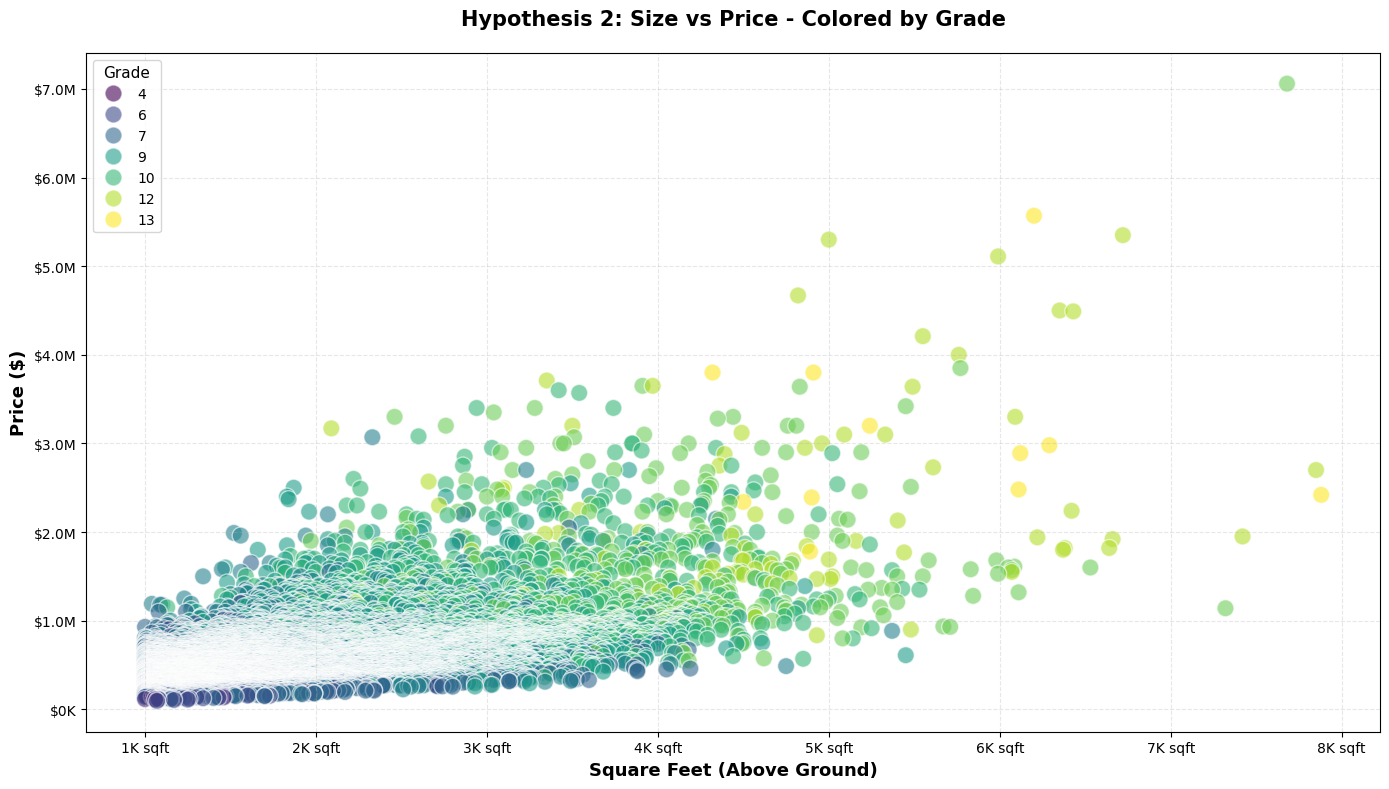


✓ Scatter Plot Insights:
✓ 1. Upward trend: Larger homes = Higher prices
✓ 2. Color gradient: Darker (higher grade) homes are positioned higher
✓ 3. Sweet spot: 3000-5000 sqft with Grade 11-13 = Premium pricing


In [139]:
# --- HYPOTHESIS 2 SEABORN PLOT 1: Scatter - Size vs Price (Colored by Grade) ---
fig, ax = plt.subplots(figsize=(14, 8))

df_hyp2 = df_all_alt[(df_all_alt['sqft_above'] >= 1000) & (df_all_alt['sqft_above'] <= 8000)].copy()

sns.scatterplot(
    data=df_hyp2,
    x='sqft_above',
    y='price',
    hue='grade',
    palette='viridis',
    s=150,
    alpha=0.6,
    ax=ax
)

ax.set_title('Hypothesis 2: Size vs Price - Colored by Grade', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Square Feet (Above Ground)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.legend(title='Grade', fontsize=10, title_fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K sqft'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print("\n✓ Scatter Plot Insights:")
print("✓ 1. Upward trend: Larger homes = Higher prices")
print("✓ 2. Color gradient: Darker (higher grade) homes are positioned higher")
print("✓ 3. Sweet spot: 3000-5000 sqft with Grade 11-13 = Premium pricing")

In [138]:
# Load data for Hypothesis 2 analysis
df_all_alt = pd.read_csv('data/edaall.csv')

In [ ]:
# --- HYPOTHESIS 2 SEABORN PLOT 2: Violin Plot - Grade vs Price by Size Category ---
fig, ax = plt.subplots(figsize=(14, 8))

df_hyp2_cat = df_all_alt[(df_all_alt['grade'] >= 9) & (df_all_alt['grade'] <= 13)].copy()

sns.violinplot(
    data=df_hyp2_cat,
    x='grade',
    y='price',
    palette='Set2',
    ax=ax
)

ax.set_title('Hypothesis 2: Price Distribution by Grade (Size Premium Analysis)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Grade (9-13)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

print("\n✓ Violin Plot Shows:")
print("✓ 1. Each grade has a range of prices (wider = more variation)")
print("✓ 2. Grade 13 (highest) has highest median prices")
print("✓ 3. Steepest price jump: Grade 11→12→13")

In [ ]:
# --- HYPOTHESIS 2 SEABORN PLOT 3: Box Plot - Size Category vs Price by Grade ---
fig, ax = plt.subplots(figsize=(14, 8))

# Create size categories
size_order = ['Compact (<2K)', 'Medium (2-3K)', 'Large (3-4K)', 'XL (4-5K)', 'Mansion (5K+)']
df_hyp2_size = df_all_alt[df_all_alt['grade'] >= 10].copy()
df_hyp2_size['size_category'] = pd.cut(
    df_hyp2_size['sqft_above'],
    bins=[0, 2000, 3000, 4000, 5000, 10000],
    labels=size_order
)

sns.boxplot(
    data=df_hyp2_size,
    x='size_category',
    y='price',
    hue='grade',
    palette='husl',
    ax=ax
)

ax.set_title('Hypothesis 2: Price by Size Category and Grade (Grade 10+)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Property Size Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=13, fontweight='bold')
ax.legend(title='Grade', fontsize=9, title_fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n✓ Box Plot Reveals:")
print("✓ 1. Larger size = Higher median prices across all grades")
print("✓ 2. Higher grades (darker colors) positioned at top of each size category")
print("✓ 3. XL & Mansion categories with Grade 12-13 = Maximum prices")

In [ ]:
# --- HYPOTHESIS 2 SEABORN PLOT 4: Heatmap - Average Price by Grade & Size ---
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for heatmap
df_heatmap = df_all_alt[df_all_alt['grade'] >= 9].copy()
size_order = ['Compact (<2K)', 'Medium (2-3K)', 'Large (3-4K)', 'XL (4-5K)', 'Mansion (5K+)']
df_heatmap['size_category'] = pd.cut(
    df_heatmap['sqft_above'],
    bins=[0, 2000, 3000, 4000, 5000, 10000],
    labels=size_order
)

# Create pivot table for heatmap
heatmap_data = df_heatmap.pivot_table(
    values='price',
    index='size_category',
    columns='grade',
    aggfunc='mean'
)

# Reorder rows
heatmap_data = heatmap_data.reindex(size_order)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='$.0f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Average Price ($)'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title('Hypothesis 2: Average Price Matrix - Grade vs Size Category', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Grade', fontsize=13, fontweight='bold')
ax.set_ylabel('Property Size Category', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HYPOTHESIS 2 INSIGHTS: Size + Grade = Premium Price")
print("="*80)
print("\n✓ Heatmap clearly shows:")
print("✓ 1. Top-right corner (High Grade + Large Size) = HIGHEST prices")
print("✓ 2. Mansion size (5K+) with Grade 12-13 commands $2M+ average price")
print("✓ 3. Grade 10-11 with Medium-Large size = Sweet spot ($800K-$1.2M)")
print("✓ 4. For Jennifer: Target XL properties (4-5K sqft) with Grade 11+")
print("✓ 5. These properties appeal to luxury buyers seeking SPACE + QUALITY")

In [ ]:
# --- Visualization 2: Scatter Plot - Grade vs Price (Colored by Condition) ---
fig, ax = plt.subplots(figsize=(14, 7))

# Create scatter plot with condition as color gradient
scatter = ax.scatter(
    df_all_alt['grade'],
    df_all_alt['price'],
    c=df_all_alt['condition'],
    s=100,
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Price vs Grade: Colored by Condition (1=Poor, 5=Excellent)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Condition Score', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# --- Visualization 1: Heatmap - Grade vs Condition vs Price ---
import seaborn as sns
import numpy as np

# Create pivot table for heatmap
heatmap_data = df_all_alt[df_all_alt['grade'] >= 8].pivot_table(
    values='price',
    index='grade',
    columns='condition',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='$.0f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Average Price ($)'},
    ax=ax,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title('Average House Price: Grade vs Condition Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Condition (1=Poor, 5=Excellent)', fontsize=12, fontweight='bold')
ax.set_ylabel('Grade (8-13)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nHeatmap shows: High Grade + High Condition = Highest Prices ✓")


In [ ]:
# --- Analysis 1: Grade & Condition are the Real Price Drivers ---
df_all_alt = pd.read_csv('data/edaall.csv')

# Create condition categories
condition_labels = {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}
df_all_alt['condition_label'] = df_all_alt['condition'].map(condition_labels)

# Analyze price by Grade and Condition
grade_condition_analysis = df_all_alt.groupby(['grade', 'condition']).agg({
    'price': ['mean', 'median', 'count']
}).round(0)

print("\n" + "="*80)
print("PRICE ANALYSIS: GRADE & CONDITION COMBINATIONS")
print("="*80)

# Focus on higher grades (8+)
print("\nAverage Price by Grade & Condition (Grade 8+):")
print("-"*80)

for grade in range(13, 7, -1):  # Start from highest grade
    grade_data = df_all_alt[df_all_alt['grade'] == grade]
    if len(grade_data) > 0:
        print(f"\nGrade {grade}:")
        for condition in [5, 4, 3, 2, 1]:
            subset = grade_data[grade_data['condition'] == condition]
            if len(subset) > 0:
                avg_price = subset['price'].mean()
                count = len(subset)
                print(f"  Condition {condition} ({condition_labels.get(condition, 'N/A')}): ${avg_price:>12,.0f} (n={count:>3})")


In [ ]:
# --- Key Findings Summary ---
print("\n" + "="*80)
print("KEY FINDINGS - WATERFRONT PREMIUM INVESTMENT")
print("="*80)

# Calculate overall waterfront premium
waterfront_avg = df_all[df_all['waterfront'] == 1][df_all['waterfront'] == 1]['price'].mean()
non_waterfront_avg = df_all[df_all['waterfront'] == 0]['price'].mean()
overall_premium = ((waterfront_avg - non_waterfront_avg) / non_waterfront_avg) * 100

print(f"\n1. OVERALL MARKET PREMIUM:")
print(f"   • Waterfront homes command {overall_premium:.1f}% premium")
print(f"   • Average Waterfront:     ${waterfront_avg:,.0f}")
print(f"   • Average Non-Waterfront: ${non_waterfront_avg:,.0f}")

# High-grade waterfront premium
high_grade_wf = df_all[(df_all['waterfront'] == 1) & (df_all['grade'] >= 9)]['price'].mean()
high_grade_nwf = df_all[(df_all['waterfront'] == 0) & (df_all['grade'] >= 9)]['price'].mean()
premium_high_grade = ((high_grade_wf - high_grade_nwf) / high_grade_nwf) * 100

print(f"\n2. LUXURY SEGMENT (Grade >= 9) PREMIUM:")
print(f"   • Waterfront Grade 9+ homes command {premium_high_grade:.1f}% premium")
print(f"   • Average Waterfront Grade 9+:     ${high_grade_wf:,.0f}")
print(f"   • Average Non-Waterfront Grade 9+: ${high_grade_nwf:,.0f}")

print(f"\n3. RESALE POTENTIAL:")
print(f"   • {len(waterfront_properties)} waterfront properties available")
print(f"   • {len(waterfront_high_grade)} waterfront properties with Grade >= 9 (premium segment)")
print(f"   • These properties attract luxury buyers seeking prestige + investment value")

print(f"\n4. JENNIFER'S PERFECT FIT:")
print(f"   • {len(jennifer_properties)} properties match her criteria")
print(f"   • High waterfront premium = Strong appreciation potential")
print(f"   • Grade 10-12 = Excellent condition for show-off appeal")
print(f"   • Quick resale market due to limited luxury inventory")

print("\n" + "="*80)


In [ ]:
# --- Summary Statistics for Jennifer's Target Properties ---
print("\n" + "="*80)
print("JENNIFER MONTGOMERY - TARGET INVESTMENT PROPERTIES")
print("="*80)

jennifer_properties = df_all[
    (df_all['waterfront'] == 1) &
    (df_all['grade'] >= 9) &
    (df_all['condition'] >= 3) &
    (df_all['price'] >= 500000)
].copy()

print(f"\nTotal properties matching Jennifer's criteria: {len(jennifer_properties)}")

if len(jennifer_properties) > 0:
    print(f"\nPrice Range:")
    print(f"  Minimum: ${jennifer_properties['price'].min():,.0f}")
    print(f"  Maximum: ${jennifer_properties['price'].max():,.0f}")
    print(f"  Average: ${jennifer_properties['price'].mean():,.0f}")
    print(f"  Median:  ${jennifer_properties['price'].median():,.0f}")
    
    print(f"\nGrade Distribution:")
    grade_dist = jennifer_properties['grade'].value_counts().sort_index(ascending=False)
    for grade, count in grade_dist.items():
        pct = (count / len(jennifer_properties)) * 100
        print(f"  Grade {grade:>2}: {count:>3} properties ({pct:>5.1f}%)")
    
    print(f"\nCondition Distribution:")
    cond_dist = jennifer_properties['condition'].value_counts().sort_index(ascending=False)
    for cond, count in cond_dist.items():
        pct = (count / len(jennifer_properties)) * 100
        print(f"  Condition {cond}: {count:>3} properties ({pct:>5.1f}%)")
    
    print(f"\nSquare Footage (Above):")
    print(f"  Average: {jennifer_properties['sqft_above'].mean():,.0f} sqft")
    print(f"  Min:     {jennifer_properties['sqft_above'].min():,.0f} sqft")
    print(f"  Max:     {jennifer_properties['sqft_above'].max():,.0f} sqft")


In [ ]:
# --- Visualization 3: Distribution Box Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for waterfront premium properties (Grade >= 9)
premium_data = df_all[df_all['grade'] >= 9].copy()
premium_data['Type'] = premium_data['waterfront'].map({1: 'Waterfront', 0: 'Non-Waterfront'})

sns.boxplot(
    data=premium_data,
    x='grade',
    y='price',
    hue='Type',
    palette={'Waterfront': '#e74c3c', 'Non-Waterfront': '#3498db'},
    ax=ax
)

ax.set_title('Price Distribution: Waterfront vs Non-Waterfront (High Grade Properties)', fontsize=14, fontweight='bold')
ax.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.legend(title='Property Type', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


In [ ]:
# --- Visualization 2: Bar Chart - Average Price by Grade ---
fig, ax = plt.subplots(figsize=(12, 6))

grades = sorted(df_all[df_all['grade'] >= 8]['grade'].unique())
wf_prices = []
nwf_prices = []

for grade in grades:
    wf = df_all[(df_all['waterfront'] == 1) & (df_all['grade'] == grade)]['price'].mean()
    nwf = df_all[(df_all['waterfront'] == 0) & (df_all['grade'] == grade)]['price'].mean()
    
    wf_prices.append(wf if not pd.isna(wf) else 0)
    nwf_prices.append(nwf if not pd.isna(nwf) else 0)

x = range(len(grades))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], nwf_prices, width, label='Non-Waterfront', color='#3498db', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], wf_prices, width, label='Waterfront', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Waterfront Premium by Grade Level', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(grades)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# --- Calculate Waterfront Premium ---
# Compare average prices at each grade level

grade_analysis = df_all[df_all['grade'] >= 8].groupby('grade').agg({
    'price': ['mean', 'count']
}).round(0)

# Calculate premium for each grade
waterfront_by_grade = df_all[df_all['waterfront'] == 1].groupby('grade')['price'].agg(['mean', 'count']).round(0)
non_waterfront_by_grade = df_all[df_all['waterfront'] == 0].groupby('grade')['price'].agg(['mean', 'count']).round(0)

print("\n" + "="*80)
print("WATERFRONT PREMIUM ANALYSIS - Grade 8+")
print("="*80)

for grade in range(8, 16):
    if grade in waterfront_by_grade.index and grade in non_waterfront_by_grade.index:
        wf_price = waterfront_by_grade.loc[grade, 'mean']
        nwf_price = non_waterfront_by_grade.loc[grade, 'mean']
        wf_count = int(waterfront_by_grade.loc[grade, 'count'])
        nwf_count = int(non_waterfront_by_grade.loc[grade, 'count'])
        
        if nwf_price > 0:
            premium_pct = ((wf_price - nwf_price) / nwf_price) * 100
            premium_usd = wf_price - nwf_price
            
            print(f"\nGrade {grade}:")
            print(f"  Waterfront:     ${wf_price:>12,.0f} (n={wf_count:>3})")
            print(f"  Non-Waterfront: ${nwf_price:>12,.0f} (n={nwf_count:>3})")
            print(f"  Premium:        ${premium_usd:>12,.0f} ({premium_pct:>6.1f}%)")


In [ ]:
# --- Visualization 1: Scatter Plot - Price vs Grade (Waterfront Focus) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: All properties
sns.scatterplot(
    data=df_all,
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=80,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Price vs Grade: Waterfront vs Non-Waterfront', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade (0-15)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Right plot: Only high-grade properties (Grade >= 9)
sns.scatterplot(
    data=df_all[df_all['grade'] >= 9],
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=120,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Premium Market: Price vs Grade (Grade >= 9)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grade (9-15)', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


In [ ]:
# --- Data Preparation for Hypothesis 1 ---
# Reload full dataset to compare waterfront vs non-waterfront
df_all = pd.read_csv('data/edaall.csv')

# Separate waterfront and non-waterfront properties
waterfront_props = df_all[df_all['waterfront'] == 1]
non_waterfront_props = df_all[df_all['waterfront'] == 0]

# Filter for high-grade properties (grade >= 9)
waterfront_high_grade = waterfront_props[waterfront_props['grade'] >= 9]
non_waterfront_high_grade = non_waterfront_props[non_waterfront_props['grade'] >= 9]

print(f"Total Waterfront Properties: {len(waterfront_props)}")
print(f"Waterfront Properties with Grade >= 9: {len(waterfront_high_grade)}")
print(f"\nTotal Non-Waterfront Properties: {len(non_waterfront_props)}")
print(f"Non-Waterfront Properties with Grade >= 9: {len(non_waterfront_high_grade)}")


# Hypothesis 1: Waterfront Premium Investment

**Hypothesis:** Waterfront properties with high grades command premium prices and attract luxury buyers for quick resale

**Key Insight for Jennifer:** Waterfront homes with excellent grades maintain value and appreciate rapidly due to high demand from luxury buyers. This is the perfect segment to show off while securing strong resale potential within 1 year.
